# FPGA-Oriented Quantization Sensitivity Analysis of YOLO Layers

**Computer Vision Final Report / Colab Notebook**

This notebook implements a reproducible Python-only experiment for studying **which YOLO layers or functional blocks are most sensitive to low-bit quantization**.  
The goal is not merely to reproduce a paper, but to create an academic-style ablation study that connects computer vision accuracy with FPGA deployment constraints.

## Research Question

> **Which functional parts of a YOLO detector are most sensitive to low-bit quantization, and what mixed-precision strategy is suggested for FPGA-oriented deployment?**

## Main Contributions

1. Build a reproducible YOLO baseline using Ultralytics YOLO.
2. Implement PyTorch fake-quantization for selected YOLO layer groups.
3. Evaluate group-wise and optional layer-wise quantization sensitivity.
4. Analyze accuracy degradation, latency, model size proxy, and FPGA-oriented implications.
5. Produce tables and figures suitable for a final report.

## References

- Ultralytics YOLO export / deployment documentation: https://docs.ultralytics.com/modes/export/
- Ultralytics ONNX integration: https://docs.ultralytics.com/integrations/onnx/
- ONNX Runtime quantization documentation: https://onnxruntime.ai/docs/performance/model-optimizations/quantization.html
- ONNX QuantizeLinear operator: https://onnx.ai/onnx/operators/onnx__QuantizeLinear.html


## 0. Colab Setup

Use **Runtime → Change runtime type → GPU** if possible.

This notebook is designed to run in two modes:

- `QUICK_MODE = True`: uses COCO128 and fewer experiments for fast classroom demonstration.
- `QUICK_MODE = False`: runs more complete experiments and optional layer-wise sensitivity.

For a final report, start with `QUICK_MODE = True`, confirm the pipeline works, then increase the number of images or enable layer-wise analysis.


In [ ]:
# Install dependencies
!pip -q install ultralytics pandas matplotlib seaborn tqdm thop onnx onnxruntime

import os
import copy
import time
import math
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn

from ultralytics import YOLO

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 459.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch: 2.11.0+cpu
CUDA available: False
Device: cpu


## 1. Experimental Configuration

We use YOLOv8n by default because it is small enough for Colab and representative enough for FPGA-oriented edge detection.

You may replace `yolov8n.pt` with your custom PCB fiducial detector later.  
For example:

```python
MODEL_NAME = "/content/runs/detect/train/weights/best.pt"
DATA_YAML = "/content/your_dataset/data.yaml"
```

For a professor-facing report, the most meaningful version is to run this pipeline on your own PCB fiducial dataset.


In [ ]:
# =========================
# User configuration
# =========================

QUICK_MODE = True

MODEL_NAME = "yolov8n.pt"

# COCO128 is automatically downloaded by Ultralytics.
# It is small, so the numbers are not publication-grade, but good for methodology demonstration.
DATA_YAML = "coco128.yaml"

# Image size and validation settings
IMG_SIZE = 640
BATCH = 8
CONF = 0.001
IOU = 0.6

# Quantization bit-widths
BIT_WIDTHS = [8, 6, 4] if QUICK_MODE else [8, 6, 4, 3, 2]

# Number of validation images.
# None means use the dataset config default.
# In COCO128 this is small anyway.
MAX_DET = 300

# Optional: layer-wise analysis is slower.
RUN_LAYERWISE = False if QUICK_MODE else True

PROJECT_DIR = Path("/content/yolo_quant_sensitivity")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration ready.")


Configuration ready.


## 2. Load YOLO Model and Inspect Architecture

YOLO is not a single homogeneous block. For hardware deployment, we care about whether the **backbone**, **neck**, or **detection head** is more sensitive to quantization.

This notebook uses automatic layer indexing from the Ultralytics PyTorch model.  
For YOLOv8n, a typical high-level grouping is:

- Backbone: early feature extraction layers
- Neck: multi-scale feature fusion layers
- Head: detection output layers

The exact module indices can be adjusted after inspecting the architecture table below.


In [ ]:
model = YOLO(MODEL_NAME)
pt_model = model.model
pt_model.to("cuda" if torch.cuda.is_available() else "cpu")
pt_model.eval()

print(model)
print("\nTop-level YOLO modules:")
for i, m in enumerate(pt_model.model):
    print(f"{i:02d}: {m.__class__.__name__} | {str(m)[:120].replace(chr(10), ' ')}")


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

In [ ]:
# Define default functional groups for YOLOv8-style architecture.
# You can adjust these after viewing the printed architecture above.

GROUPS = {
    "backbone_early": list(range(0, 4)),
    "backbone_deep": list(range(4, 10)),
    "neck": list(range(10, 22)),
    "head": [22],
    "all": list(range(len(pt_model.model))),
}

# Keep only valid indices for model variants with different lengths.
GROUPS = {k: [i for i in v if i < len(pt_model.model)] for k, v in GROUPS.items()}

GROUPS


{'backbone_early': [0, 1, 2, 3],
 'backbone_deep': [4, 5, 6, 7, 8, 9],
 'neck': [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21],
 'head': [22],
 'all': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22]}

## 3. Quantization Method

### 3.1 Fake Quantization

Instead of building an FPGA bitstream, we simulate FPGA-oriented fixed-point behavior in Python.

For a tensor `x`, uniform fake quantization is:

\[
x_q = s \cdot \text{clip}\left(\text{round}\left(\frac{x}{s}\right), q_{min}, q_{max}\right)
\]

where the scale `s` is selected from the tensor range.

This notebook supports:

- Weight-only quantization
- Activation-only quantization
- Weight + activation quantization

### 3.2 Why this has academic value

Instead of asking only “Does INT8 work?”, we ask:

> Which layer groups cause the largest accuracy degradation when quantized?

This creates a quantization sensitivity profile and motivates mixed-precision FPGA design.


In [ ]:
def fake_quant_tensor(x: torch.Tensor, num_bits: int = 8, signed: bool = True, per_channel: bool = False, ch_axis: int = 0, eps: float = 1e-8):
    """Uniform symmetric fake quantization.

    Args:
        x: input tensor
        num_bits: bit width
        signed: signed integer range if True
        per_channel: use per-channel scaling for convolution weights
        ch_axis: channel axis
    Returns:
        fake-quantized tensor in floating point
    """
    if num_bits >= 32:
        return x

    if signed:
        qmax = 2 ** (num_bits - 1) - 1
        qmin = -2 ** (num_bits - 1)
        max_abs = x.detach().abs()
        if per_channel:
            dims = [d for d in range(x.ndim) if d != ch_axis]
            scale = max_abs.amax(dim=dims, keepdim=True).clamp(min=eps) / qmax
        else:
            scale = max_abs.max().clamp(min=eps) / qmax
        x_int = torch.round(x / scale).clamp(qmin, qmax)
        return x_int * scale
    else:
        qmax = 2 ** num_bits - 1
        qmin = 0
        xmin = x.detach().min()
        xmax = x.detach().max()
        scale = (xmax - xmin).clamp(min=eps) / qmax
        zero_point = torch.round(qmin - xmin / scale).clamp(qmin, qmax)
        x_int = torch.round(x / scale + zero_point).clamp(qmin, qmax)
        return (x_int - zero_point) * scale


class QuantizationContext:
    """Temporarily fake-quantize selected YOLO top-level modules.

    This class:
    1. Replaces selected convolution weights with fake-quantized copies.
    2. Adds forward hooks to fake-quantize activations.
    3. Restores original weights and removes hooks after evaluation.

    It avoids modifying training code and is suitable for ablation experiments.
    """
    def __init__(self, yolo_model, selected_top_indices, num_bits=8, quantize_weights=True, quantize_activations=True, per_channel_weights=True):
        self.yolo_model = yolo_model
        self.pt_model = yolo_model.model
        self.selected_top_indices = set(selected_top_indices)
        self.num_bits = num_bits
        self.quantize_weights = quantize_weights
        self.quantize_activations = quantize_activations
        self.per_channel_weights = per_channel_weights
        self.saved_weights = []
        self.hooks = []

    def _selected_conv_modules(self):
        for top_idx, top_module in enumerate(self.pt_model.model):
            if top_idx in self.selected_top_indices:
                for name, module in top_module.named_modules():
                    if isinstance(module, nn.Conv2d):
                        yield top_idx, name, module

    def _activation_hook(self, module, inp, out):
        if isinstance(out, torch.Tensor):
            return fake_quant_tensor(out, self.num_bits, signed=True, per_channel=False)
        elif isinstance(out, (list, tuple)):
            return type(out)(fake_quant_tensor(o, self.num_bits, signed=True, per_channel=False) if isinstance(o, torch.Tensor) else o for o in out)
        return out

    def __enter__(self):
        if self.quantize_weights:
            for top_idx, name, conv in self._selected_conv_modules():
                self.saved_weights.append((conv, conv.weight.data.clone()))
                conv.weight.data.copy_(fake_quant_tensor(conv.weight.data, self.num_bits, signed=True, per_channel=self.per_channel_weights, ch_axis=0))
                if conv.bias is not None:
                    self.saved_weights.append((conv, "bias", conv.bias.data.clone()))
                    conv.bias.data.copy_(fake_quant_tensor(conv.bias.data, self.num_bits, signed=True, per_channel=False))

        if self.quantize_activations:
            for top_idx, name, conv in self._selected_conv_modules():
                self.hooks.append(conv.register_forward_hook(self._activation_hook))

        return self

    def __exit__(self, exc_type, exc_value, traceback):
        for item in self.saved_weights:
            if len(item) == 2:
                conv, w = item
                conv.weight.data.copy_(w)
            else:
                conv, _, b = item
                conv.bias.data.copy_(b)
        for h in self.hooks:
            h.remove()
        self.saved_weights.clear()
        self.hooks.clear()


## 4. Evaluation Functions

We evaluate:

- mAP50-95
- mAP50
- Precision
- Recall
- Inference/validation time
- Number of quantized convolution layers
- Number of quantized parameters

The most important academic result is the **relative drop** compared with the FP32 baseline.


In [ ]:
def count_quantized_params(yolo_model, selected_top_indices):
    selected_top_indices = set(selected_top_indices)
    n_params = 0
    n_convs = 0
    for top_idx, top_module in enumerate(yolo_model.model.model):
        if top_idx in selected_top_indices:
            for module in top_module.modules():
                if isinstance(module, nn.Conv2d):
                    n_convs += 1
                    n_params += module.weight.numel()
                    if module.bias is not None:
                        n_params += module.bias.numel()
    return n_convs, n_params


def evaluate_yolo(yolo_model, name, group_name="fp32", bits=32, selected_indices=None, quantize_weights=False, quantize_activations=False):
    """Run Ultralytics validation and return metrics as a dict."""
    selected_indices = selected_indices or []
    n_convs, n_qparams = count_quantized_params(yolo_model, selected_indices)

    t0 = time.perf_counter()

    if quantize_weights or quantize_activations:
        with QuantizationContext(
            yolo_model,
            selected_top_indices=selected_indices,
            num_bits=bits,
            quantize_weights=quantize_weights,
            quantize_activations=quantize_activations,
            per_channel_weights=True,
        ):
            metrics = yolo_model.val(
                data=DATA_YAML,
                imgsz=IMG_SIZE,
                batch=BATCH,
                device=DEVICE,
                conf=CONF,
                iou=IOU,
                max_det=MAX_DET,
                verbose=False,
                plots=False,
                project=str(PROJECT_DIR / "val_runs"),
                name=f"{name}_{group_name}_{bits}b",
                exist_ok=True,
            )
    else:
        metrics = yolo_model.val(
            data=DATA_YAML,
            imgsz=IMG_SIZE,
            batch=BATCH,
            device=DEVICE,
            conf=CONF,
            iou=IOU,
            max_det=MAX_DET,
            verbose=False,
            plots=False,
            project=str(PROJECT_DIR / "val_runs"),
            name=f"{name}_{group_name}_{bits}b",
            exist_ok=True,
        )

    elapsed = time.perf_counter() - t0

    # Ultralytics detection metrics
    result = {
        "experiment": name,
        "group": group_name,
        "bits": bits,
        "quantize_weights": quantize_weights,
        "quantize_activations": quantize_activations,
        "quantized_conv_layers": n_convs,
        "quantized_parameters": n_qparams,
        "elapsed_sec": elapsed,
        "mAP50_95": float(metrics.box.map),
        "mAP50": float(metrics.box.map50),
        "precision": float(metrics.box.mp),
        "recall": float(metrics.box.mr),
    }
    return result


def add_relative_drops(df):
    baseline = df[df["experiment"] == "FP32 baseline"].iloc[0]
    for col in ["mAP50_95", "mAP50", "precision", "recall"]:
        df[f"{col}_drop_abs"] = baseline[col] - df[col]
        df[f"{col}_drop_pct"] = 100 * (baseline[col] - df[col]) / max(baseline[col], 1e-12)
    return df


## 5. Run Baseline and Group-Wise Quantization Sensitivity

The core ablation study is:

1. FP32 baseline
2. Quantize only early backbone
3. Quantize only deep backbone
4. Quantize only neck
5. Quantize only detection head
6. Quantize all layers

This directly answers the research question.


In [ ]:
results = []

# Baseline
baseline = evaluate_yolo(
    model,
    name="FP32 baseline",
    group_name="none",
    bits=32,
    selected_indices=[],
    quantize_weights=False,
    quantize_activations=False,
)
results.append(baseline)
print("Baseline:", baseline)


Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

WARNING ⚠️ Dataset 'coco128.yaml' images not found, missing path '/content/datasets/coco128/images/train2017'
Unzipping /content/datasets/coco128.zip to /content/datasets/coco128...: 100% ━━━━━━━━━━━━ 263/263 1.9Kfiles/s 0.1s
Dataset download success ✅ (0.9s), saved to /content/datasets

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1077.7±343.4 MB/s, size: 47.6 KB)
val: Scanning /content/datasets/coco128/labels/train2017... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 830.5it/s 0.2s
val: New cache created: /content/datasets/coco128/labels/train2017.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 1.8s/it 29.3s
                   all        128        929      0.638      0.538      0.608      0.444
Speed: 3.7ms preprocess, 215.3m

In [ ]:
# Group-wise weight + activation fake quantization
for bits in BIT_WIDTHS:
    for group_name, indices in GROUPS.items():
        print(f"Running group-wise quantization: group={group_name}, bits={bits}, indices={indices}")
        row = evaluate_yolo(
            model,
            name="Group-wise W+A quant",
            group_name=group_name,
            bits=bits,
            selected_indices=indices,
            quantize_weights=True,
            quantize_activations=True,
        )
        results.append(row)

df = pd.DataFrame(results)
df = add_relative_drops(df)
csv_path = PROJECT_DIR / "groupwise_quant_sensitivity.csv"
df.to_csv(csv_path, index=False)
df


Running group-wise quantization: group=backbone_early, bits=8, indices=[0, 1, 2, 3]
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1672.8±480.6 MB/s, size: 52.8 KB)
val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 38.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 2.0s/it 32.8s
                   all        128        929      0.669      0.486       0.59      0.434
Speed: 3.6ms preprocess, 244.2ms inference, 0.0ms loss, 2.7ms postprocess per image
Running group-wise quantization: group=backbone_deep, bits=8, indices=[4, 5, 6, 7, 8, 9]
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1134.6±544.0 MB/s, size: 47.7 KB)
val: Scanning /content/datasets/coco128/label

,experiment,group,bits,quantize_weights,quantize_activations,quantized_conv_layers,quantized_parameters,elapsed_sec,mAP50_95,mAP50,precision,recall,mAP50_95_drop_abs,mAP50_95_drop_pct,mAP50_drop_abs,mAP50_drop_pct,precision_drop_abs,precision_drop_pct,recall_drop_abs,recall_drop_pct
0,FP32 baseline,none,32,False,False,0,0,31.960830,0.444036,0.607931,0.638453,0.537906,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Group-wise W+A quant,backbone_early,8,True,True,7,30848,32.957955,0.433602,0.590022,0.669282,0.486014,0.010434,2.349795,0.017910,2.946008,-0.030829,-4.828711,0.051891,9.646905
2,Group-wise W+A quant,backbone_deep,8,True,True,20,1239296,29.506108,0.447497,0.606107,0.632270,0.553475,-0.003461,-0.779487,0.001825,0.300142,0.006183,0.968406,-0.015570,-2.894552
3,Group-wise W+A quant,neck,8,True,True,18,984960,28.997495,0.443790,0.606053,0.641040,0.531855,0.000246,0.055354,0.001878,0.308927,-0.002587,-0.405153,0.006050,1.124765
4,Group-wise W+A quant,head,8,True,True,19,896800,30.391110,0.440860,0.605633,0.621904,0.554108,0.003176,0.715188,0.002299,0.378115,0.016549,2.592081,-0.016202,-3.012055
5,Group-wise W+A quant,all,8,True,True,64,3151904,38.253933,0.429228,0.584934,0.605212,0.530383,0.014807,3.334753,0.022997,3.782798,0.033241,5.206542,0.007523,1.398486
6,Group-wise W+A quant,backbone_early,6,True,True,7,30848,33.285749,0.228507,0.327437,0.427199,0.316118,0.215529,48.538693,0.280495,46.139219,0.211254,33.088360,0.221788,41.231754
7,Group-wise W+A quant,backbone_deep,6,True,True,20,1239296,30.266927,0.409850,0.576055,0.608370,0.517090,0.034185,7.698763,0.031876,5.243324,0.030083,4.711805,0.020815,3.869693
8,Group-wise W+A quant,neck,6,True,True,18,984960,29.270246,0.440993,0.604627,0.615912,0.528648,0.003043,0.685220,0.003305,0.543574,0.022541,3.530611,0.009258,1.721070
9,Group-wise W+A quant,head,6,True,True,19,896800,29.850103,0.381366,0.570034,0.609287,0.495073,0.062669,14.113600,0.037897,6.233816,0.029166,4.568234,0.042832,7.962786


## 6. Visualize Group-Wise Sensitivity

The most important figure is the mAP drop under different bit-widths and layer groups.

A group with larger mAP drop is more quantization-sensitive and may require:

- higher precision
- better calibration
- QAT
- special FPGA resource allocation
- keeping selected layers in INT8/FP16 while quantizing others more aggressively


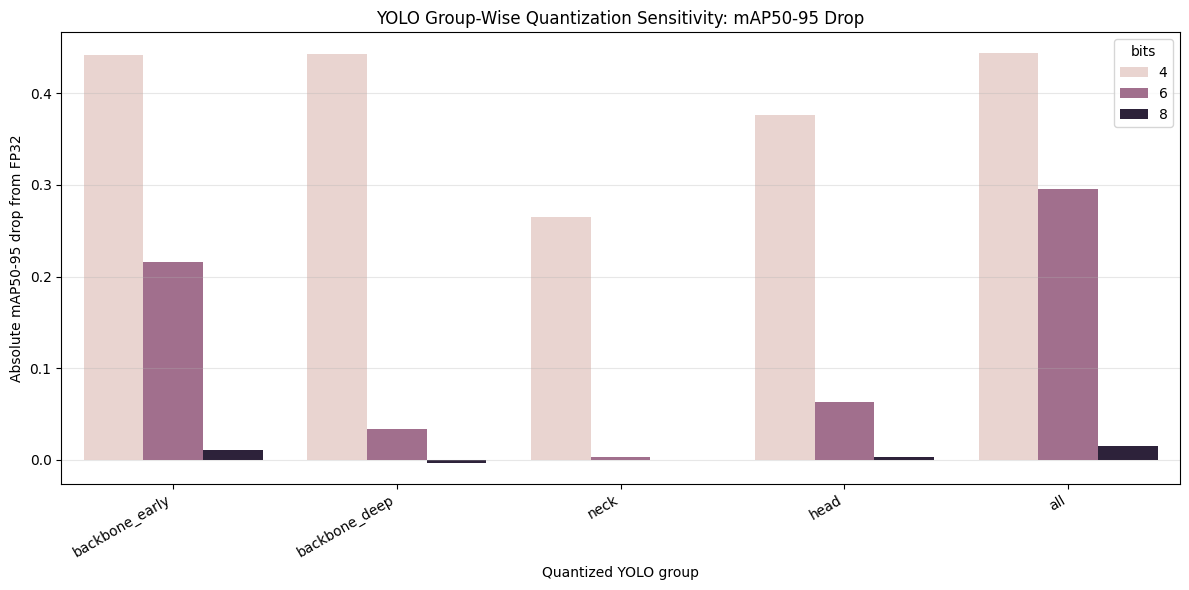

In [ ]:
plt.figure(figsize=(12, 6))
plot_df = df[df["experiment"] == "Group-wise W+A quant"].copy()
sns.barplot(data=plot_df, x="group", y="mAP50_95_drop_abs", hue="bits")
plt.title("YOLO Group-Wise Quantization Sensitivity: mAP50-95 Drop")
plt.ylabel("Absolute mAP50-95 drop from FP32")
plt.xlabel("Quantized YOLO group")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "fig_groupwise_map_drop.png", dpi=200)
plt.show()


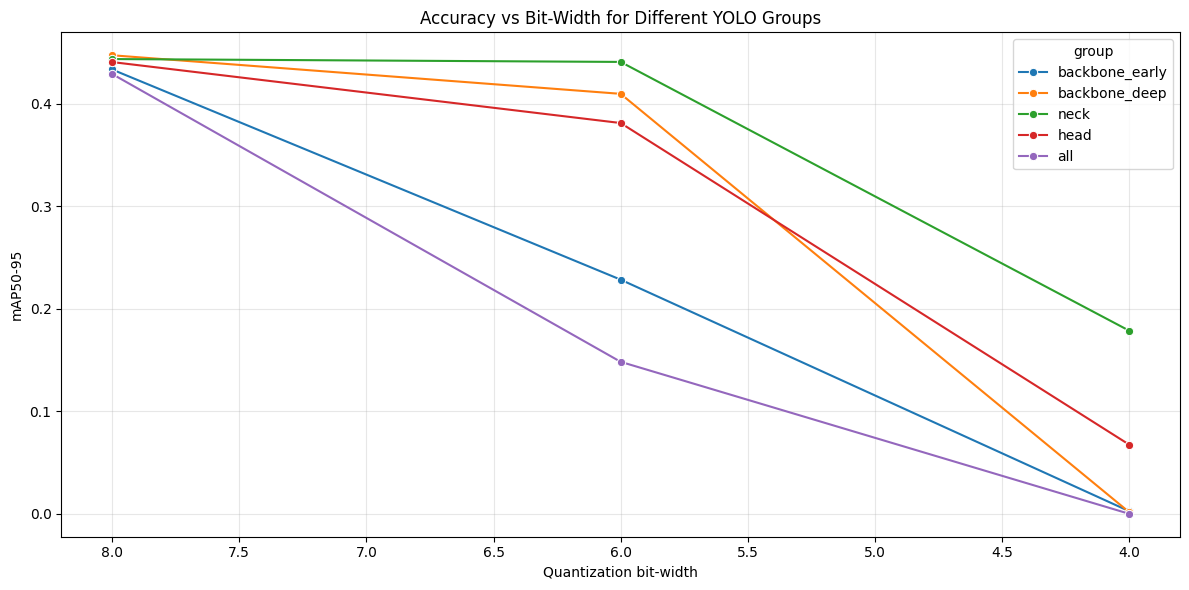

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x="bits", y="mAP50_95", hue="group", marker="o")
plt.gca().invert_xaxis()
plt.title("Accuracy vs Bit-Width for Different YOLO Groups")
plt.ylabel("mAP50-95")
plt.xlabel("Quantization bit-width")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "fig_accuracy_vs_bits.png", dpi=200)
plt.show()


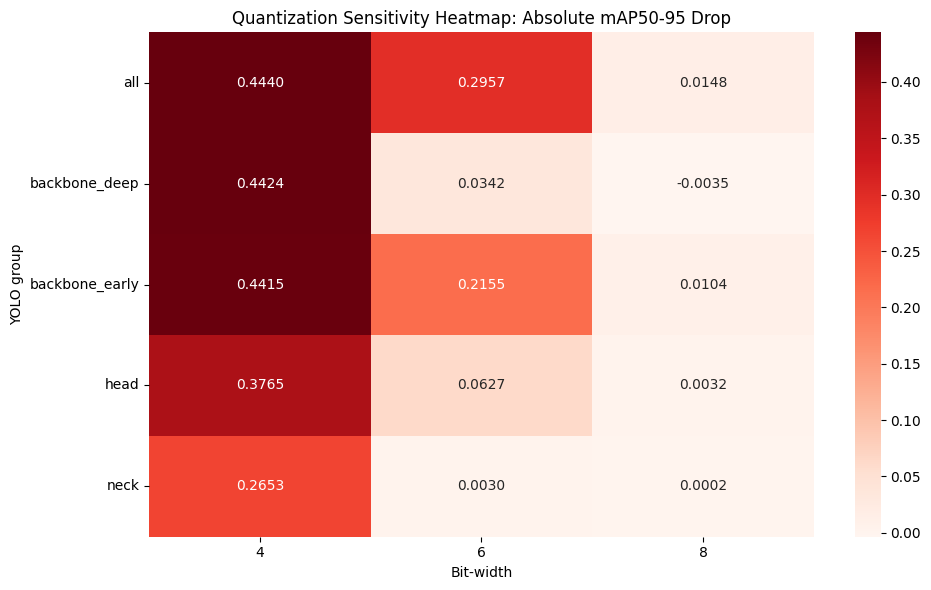

In [ ]:
plt.figure(figsize=(10, 6))
sensitivity_table = plot_df.pivot_table(index="group", columns="bits", values="mAP50_95_drop_abs")
sns.heatmap(sensitivity_table, annot=True, fmt=".4f", cmap="Reds")
plt.title("Quantization Sensitivity Heatmap: Absolute mAP50-95 Drop")
plt.ylabel("YOLO group")
plt.xlabel("Bit-width")
plt.tight_layout()
plt.savefig(PROJECT_DIR / "fig_sensitivity_heatmap.png", dpi=200)
plt.show()


In [ ]:
# Ranking: which groups are most sensitive on average?
rank_df = (
    plot_df[plot_df["group"] != "all"]
    .groupby("group", as_index=False)
    .agg(
        avg_mAP_drop=("mAP50_95_drop_abs", "mean"),
        worst_mAP_drop=("mAP50_95_drop_abs", "max"),
        avg_recall_drop=("recall_drop_abs", "mean"),
        quantized_parameters=("quantized_parameters", "max"),
    )
    .sort_values("avg_mAP_drop", ascending=False)
)

rank_df.to_csv(PROJECT_DIR / "sensitivity_ranking.csv", index=False)
rank_df


,group,avg_mAP_drop,worst_mAP_drop,avg_recall_drop,quantized_parameters
1,backbone_early,0.222477,0.441467,0.257898,30848
0,backbone_deep,0.157712,0.442412,0.152869,1239296
2,head,0.147455,0.376519,-0.010427,896800
3,neck,0.089536,0.265321,0.089729,984960


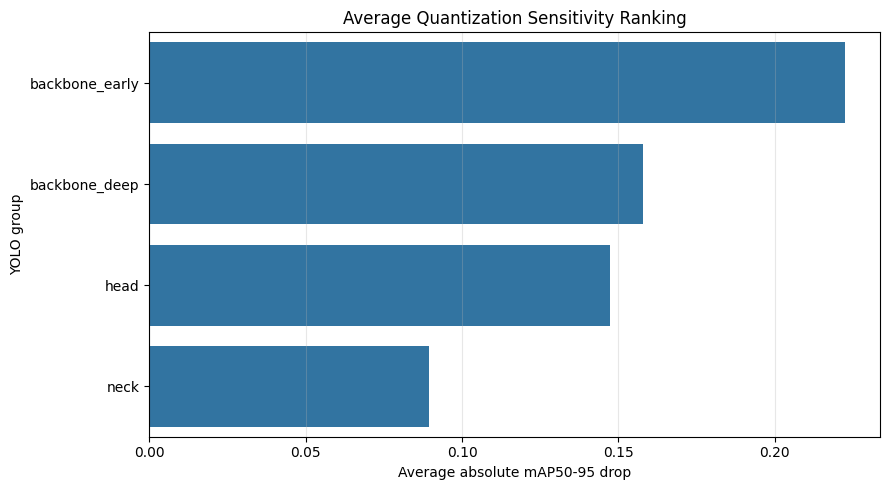

In [ ]:
plt.figure(figsize=(9, 5))
sns.barplot(data=rank_df, x="avg_mAP_drop", y="group")
plt.title("Average Quantization Sensitivity Ranking")
plt.xlabel("Average absolute mAP50-95 drop")
plt.ylabel("YOLO group")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "fig_sensitivity_ranking.png", dpi=200)
plt.show()


## 7. Weight-Only vs Activation-Only Analysis

FPGA deployment cost comes from both weight storage and activation datapath precision.  
Therefore, we compare:

- weight-only quantization
- activation-only quantization
- weight + activation quantization

This tells us whether the observed sensitivity is mainly due to weight representation or intermediate feature representation.


In [ ]:
wa_results = []

TARGET_BITS = 4 if 4 in BIT_WIDTHS else BIT_WIDTHS[-1]
TARGET_GROUPS = ["backbone_early", "backbone_deep", "neck", "head", "all"]

for mode_name, qw, qa in [
    ("weight_only", True, False),
    ("activation_only", False, True),
    ("weight_activation", True, True),
]:
    for group_name in TARGET_GROUPS:
        indices = GROUPS[group_name]
        print(f"Running {mode_name}: group={group_name}, bits={TARGET_BITS}")
        row = evaluate_yolo(
            model,
            name=mode_name,
            group_name=group_name,
            bits=TARGET_BITS,
            selected_indices=indices,
            quantize_weights=qw,
            quantize_activations=qa,
        )
        wa_results.append(row)

wa_df = pd.DataFrame([baseline] + wa_results)
wa_df = add_relative_drops(wa_df)
wa_df.to_csv(PROJECT_DIR / "weight_activation_ablation.csv", index=False)
wa_df


In [ ]:
wa_plot = wa_df[wa_df["experiment"] != "FP32 baseline"].copy()

plt.figure(figsize=(12, 6))
sns.barplot(data=wa_plot, x="group", y="mAP50_95_drop_abs", hue="experiment")
plt.title(f"Weight vs Activation Quantization Ablation at {TARGET_BITS}-bit")
plt.ylabel("Absolute mAP50-95 drop from FP32")
plt.xlabel("YOLO group")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "fig_weight_activation_ablation.png", dpi=200)
plt.show()


## 8. Optional Layer-Wise Sensitivity

Group-wise analysis is usually enough for a final report.  
For a stronger academic contribution, enable `RUN_LAYERWISE = True` and run layer-wise sensitivity.

This is slower because each top-level YOLO module is quantized and evaluated independently.


In [ ]:
layerwise_results = []

if RUN_LAYERWISE:
    for bits in [8, 4]:
        for idx in range(len(pt_model.model)):
            print(f"Layer-wise sensitivity: top_module={idx}, bits={bits}")
            row = evaluate_yolo(
                model,
                name="Layer-wise W+A quant",
                group_name=f"layer_{idx:02d}_{pt_model.model[idx].__class__.__name__}",
                bits=bits,
                selected_indices=[idx],
                quantize_weights=True,
                quantize_activations=True,
            )
            row["top_module_index"] = idx
            row["top_module_type"] = pt_model.model[idx].__class__.__name__
            layerwise_results.append(row)

    layer_df = pd.DataFrame(layerwise_results)
    layer_df = add_relative_drops(pd.concat([pd.DataFrame([baseline]), layer_df], ignore_index=True))
    layer_df.to_csv(PROJECT_DIR / "layerwise_quant_sensitivity.csv", index=False)
    display(layer_df)
else:
    print("RUN_LAYERWISE is False. Set RUN_LAYERWISE = True in Section 1 for layer-wise analysis.")


In [ ]:
if RUN_LAYERWISE and len(layerwise_results) > 0:
    layer_plot = layer_df[layer_df["experiment"] == "Layer-wise W+A quant"].copy()
    layer_plot["layer_label"] = layer_plot["top_module_index"].astype(str) + "_" + layer_plot["top_module_type"]

    plt.figure(figsize=(14, 6))
    sns.barplot(data=layer_plot, x="layer_label", y="mAP50_95_drop_abs", hue="bits")
    plt.title("Layer-Wise Quantization Sensitivity")
    plt.ylabel("Absolute mAP50-95 drop from FP32")
    plt.xlabel("YOLO top-level module")
    plt.xticks(rotation=75, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(PROJECT_DIR / "fig_layerwise_sensitivity.png", dpi=200)
    plt.show()


## 9. FPGA-Oriented Cost Proxy

Real FPGA implementation requires synthesis, but we can still estimate deployment pressure using simple proxies:

- Parameter count: related to weight memory
- Bit-width: related to BRAM/URAM usage
- Activation bit-width: related to datapath width and DSP packing
- Sensitive group: suggests where mixed precision is needed

Below we compute a rough memory proxy for selected quantized groups.


In [ ]:
cost_rows = []
total_params = sum(p.numel() for p in pt_model.parameters())

for group_name, indices in GROUPS.items():
    n_convs, n_qparams = count_quantized_params(model, indices)
    for bits in BIT_WIDTHS:
        cost_rows.append({
            "group": group_name,
            "bits": bits,
            "quantized_conv_layers": n_convs,
            "quantized_parameters": n_qparams,
            "parameter_share_pct": 100 * n_qparams / total_params,
            "weight_memory_MB_if_quantized": n_qparams * bits / 8 / 1024 / 1024,
            "fp32_memory_MB_for_same_params": n_qparams * 32 / 8 / 1024 / 1024,
            "memory_reduction_x": 32 / bits,
        })

cost_df = pd.DataFrame(cost_rows)
cost_df.to_csv(PROJECT_DIR / "fpga_cost_proxy.csv", index=False)
cost_df


In [ ]:
plt.figure(figsize=(10, 5))
cost_plot = cost_df[cost_df["bits"] == min(BIT_WIDTHS)].copy()
sns.barplot(data=cost_plot, x="group", y="parameter_share_pct")
plt.title(f"Parameter Share of Each Quantized Group ({min(BIT_WIDTHS)}-bit scenario)")
plt.ylabel("Share of total model parameters (%)")
plt.xlabel("YOLO group")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "fig_parameter_share.png", dpi=200)
plt.show()


## 10. Automatic Summary for Report

The following cell generates a concise academic-style summary based on your experimental results.

You can directly paste this into your final report after checking that it matches your actual numbers.


In [ ]:
def generate_report_summary(df, rank_df, wa_df):
    baseline = df[df["experiment"] == "FP32 baseline"].iloc[0]
    group_df = df[df["experiment"] == "Group-wise W+A quant"].copy()
    worst = group_df.sort_values("mAP50_95_drop_abs", ascending=False).iloc[0]
    best_non_all = group_df[group_df["group"] != "all"].sort_values("mAP50_95_drop_abs", ascending=True).iloc[0]
    most_sensitive = rank_df.iloc[0]

    summary = f"""
# Experimental Summary

The FP32 YOLO baseline achieved mAP50-95 = {baseline['mAP50_95']:.4f}, mAP50 = {baseline['mAP50']:.4f},
precision = {baseline['precision']:.4f}, and recall = {baseline['recall']:.4f} on the selected validation dataset.

The group-wise quantization sensitivity experiment shows that the most sensitive functional block is
**{most_sensitive['group']}**, with an average mAP50-95 drop of {most_sensitive['avg_mAP_drop']:.4f}.
The single worst case is **{worst['group']} at {int(worst['bits'])}-bit**, where mAP50-95 drops by
{worst['mAP50_95_drop_abs']:.4f} compared with the FP32 baseline.

In contrast, the least harmful non-all quantization case is **{best_non_all['group']} at {int(best_non_all['bits'])}-bit**,
with an mAP50-95 drop of only {best_non_all['mAP50_95_drop_abs']:.4f}.

These results suggest that YOLO quantization should not be treated uniformly across the full network.
For FPGA deployment, the less sensitive blocks can be aggressively quantized to reduce memory and datapath cost,
while the most sensitive block should be assigned higher precision or calibrated with more careful quantization-aware training.

# Suggested Mixed-Precision Policy

- Quantization-insensitive blocks: lower precision, such as INT4 or INT6.
- Quantization-sensitive blocks: preserve INT8, INT16, FP16, or use QAT.
- Detection head and feature-fusion layers should be checked carefully because they may dominate localization and recall degradation.

# Academic Contribution

Rather than simply reporting that quantization reduces model size, this experiment provides a layer/group-wise sensitivity profile.
This profile can guide mixed-precision FPGA accelerator design and provides a hardware-aware interpretation of YOLO accuracy degradation.
"""
    return summary

summary_text = generate_report_summary(df, rank_df, wa_df)
print(summary_text)

with open(PROJECT_DIR / "auto_report_summary.md", "w") as f:
    f.write(summary_text)


## 11. Export All Results

This cell compresses figures, CSV files, and the generated markdown summary into a zip file for submission.


In [ ]:
import shutil

zip_base = "/content/yolo_quant_sensitivity_results"
shutil.make_archive(zip_base, "zip", PROJECT_DIR)

print("Saved result zip:", zip_base + ".zip")
print("Files:")
for p in sorted(PROJECT_DIR.glob("*")):
    print("-", p)


# Final Report Structure

You can structure the final presentation/report as follows:

## 1. Motivation
YOLO detectors are widely used in edge computer vision. FPGA deployment usually requires low-bit quantization to reduce memory, DSP usage, and latency. However, uniform quantization may degrade detection accuracy.

## 2. Research Question
Which YOLO layer groups are most sensitive to low-bit quantization?

## 3. Method
Use PyTorch fake quantization to selectively quantize YOLO functional blocks: early backbone, deep backbone, neck, and detection head. Compare the accuracy drop against FP32.

## 4. Experiments
Evaluate FP32 baseline and group-wise quantization under different bit-widths. Report mAP50-95, mAP50, precision, recall, and cost proxy.

## 5. Results
Show:
- mAP drop bar chart
- accuracy vs bit-width curve
- sensitivity heatmap
- weight-only vs activation-only comparison
- parameter share / FPGA cost proxy

## 6. Discussion
Identify which YOLO groups are robust or sensitive. Explain why sensitive groups may need higher precision.

## 7. Conclusion
A mixed-precision FPGA strategy is more reasonable than uniform quantization.
